In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('HistoricData.csv')

In [3]:
# Drop rows where Mention Content ends with '...' or is NaN or is 'Deleted or protected mention'
df = df[~df['Mention Content'].str.endswith('...', na=False)]
df = df.dropna(subset=['Mention Content'])
df = df[df['Mention Content'] != 'Deleted or protected mention']

In [4]:
df['Classifiers tags'].value_counts()

Classifiers tags
Not Related To SYK/WM                          858
Mention                                        400
Not Related To SYK/WM, competitor , Mention      1
Name: count, dtype: int64

# Model Training
I need to train a text classification model on content of Mention Content column to predict whether the text is relevant or irrelevant and then do AUC-ROC analysis to pick the threshold to reduce false negatives as much as possible.

The input is Mention Content column and target is Classifiers tags column, where the distribution is as follows (drop all other)
Classifiers tags
Not Related To SYK/WM                          858
Mention                                        400
Not Related To SYK/WM, competitor , Mention      1
Name: count, dtype: int64

Not Related is negative and Mention is positive.
The model must be small since I will be using it in a node js environment which will be deployed on a CPU Azure App Service.

In [33]:
# Step 1: Prepare the data - keep only the two main classes
# Filter to only 'Not Related To SYK/WM' and 'Mention'
df_filtered = df[df['Classifiers tags'].isin(['Not Related To SYK/WM', 'Mention'])].copy()

# Create binary labels: 1 for Mention (positive), 0 for Not Related (negative)
df_filtered['label'] = (df_filtered['Classifiers tags'] == 'Mention').astype(int)

print(f"Dataset size: {len(df_filtered)}")
print(f"Class distribution:\n{df_filtered['label'].value_counts()}")
print(f"\nPositive (Mention): {df_filtered['label'].sum()}")
print(f"Negative (Not Related): {len(df_filtered) - df_filtered['label'].sum()}")

Dataset size: 1258
Class distribution:
label
0    858
1    400
Name: count, dtype: int64

Positive (Mention): 400
Negative (Not Related): 858


In [34]:
# Step 2: Split data and create TF-IDF features
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_filtered['Mention Content'].values
y = df_filtered['label'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create TF-IDF vectorizer (keep it small for Node.js deployment)
vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit features for smaller model
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2,
    max_df=0.95,
    lowercase=True,
    strip_accents='unicode'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training set size: {X_train_tfidf.shape}")
print(f"Test set size: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Training set size: (1006, 5000)
Test set size: (252, 5000)
Vocabulary size: 5000


In [35]:
# Step 3: Train a Logistic Regression model (lightweight and fast)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Train model with class weight to handle imbalance
model = LogisticRegression(
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000,
    C=1.0,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

# Get probability predictions
y_train_proba = model.predict_proba(X_train_tfidf)[:, 1]
y_test_proba = model.predict_proba(X_test_tfidf)[:, 1]

print("Model trained successfully!")
print(f"Training AUC-ROC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test AUC-ROC: {roc_auc_score(y_test, y_test_proba):.4f}")

Model trained successfully!
Training AUC-ROC: 0.9951
Test AUC-ROC: 0.9647


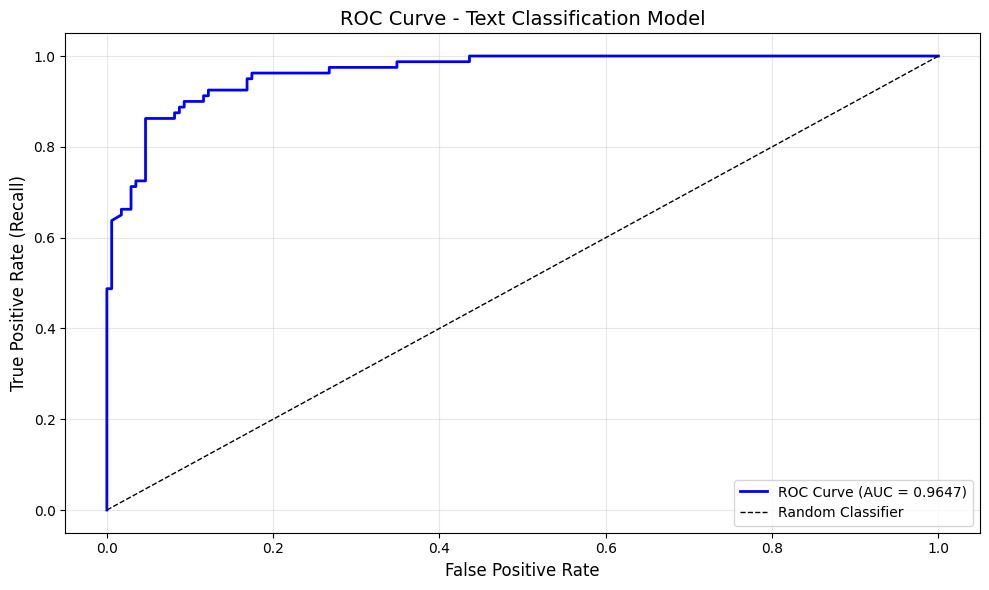

In [36]:
# Step 4: AUC-ROC Analysis and Threshold Optimization
import matplotlib.pyplot as plt
import numpy as np

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Text Classification Model', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Step 5: Find optimal threshold to minimize False Negatives
from sklearn.metrics import confusion_matrix, precision_recall_curve, f1_score

# Calculate precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_test_proba)

# Find thresholds that achieve high recall (low false negatives)
# We want to minimize false negatives, so we prioritize recall
target_recalls = [0.90, 0.95, 0.98]

print("THRESHOLD ANALYSIS TO MINIMIZE FALSE NEGATIVES")

for target_recall in target_recalls:
    # Find threshold that achieves at least target recall
    valid_indices = np.where(recall >= target_recall)[0]
    if len(valid_indices) > 0:
        # Get the threshold with highest precision among those with sufficient recall
        best_idx = valid_indices[np.argmax(precision[valid_indices])]
        if best_idx < len(pr_thresholds):
            thresh = pr_thresholds[best_idx]
            
            # Calculate metrics at this threshold
            y_pred_thresh = (y_test_proba >= thresh).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
            
            print(f"\nTarget Recall >= {target_recall:.0%}:")
            print(f"  Threshold: {thresh:.4f}")
            print(f"  Actual Recall: {tp/(tp+fn):.4f}")
            print(f"  Precision: {tp/(tp+fp):.4f}")
            print(f"  F1 Score: {f1_score(y_test, y_pred_thresh):.4f}")
            print(f"  False Negatives: {fn}")
            print(f"  False Positives: {fp}")

THRESHOLD ANALYSIS TO MINIMIZE FALSE NEGATIVES

Target Recall >= 90%:
  Threshold: 0.5240
  Actual Recall: 0.9000
  Precision: 0.8182
  F1 Score: 0.8571
  False Negatives: 8
  False Positives: 16

Target Recall >= 95%:
  Threshold: 0.4780
  Actual Recall: 0.9500
  Precision: 0.7238
  F1 Score: 0.8216
  False Negatives: 4
  False Positives: 29

Target Recall >= 98%:
  Threshold: 0.3609
  Actual Recall: 0.9875
  Precision: 0.5683
  F1 Score: 0.7215
  False Negatives: 1
  False Positives: 60


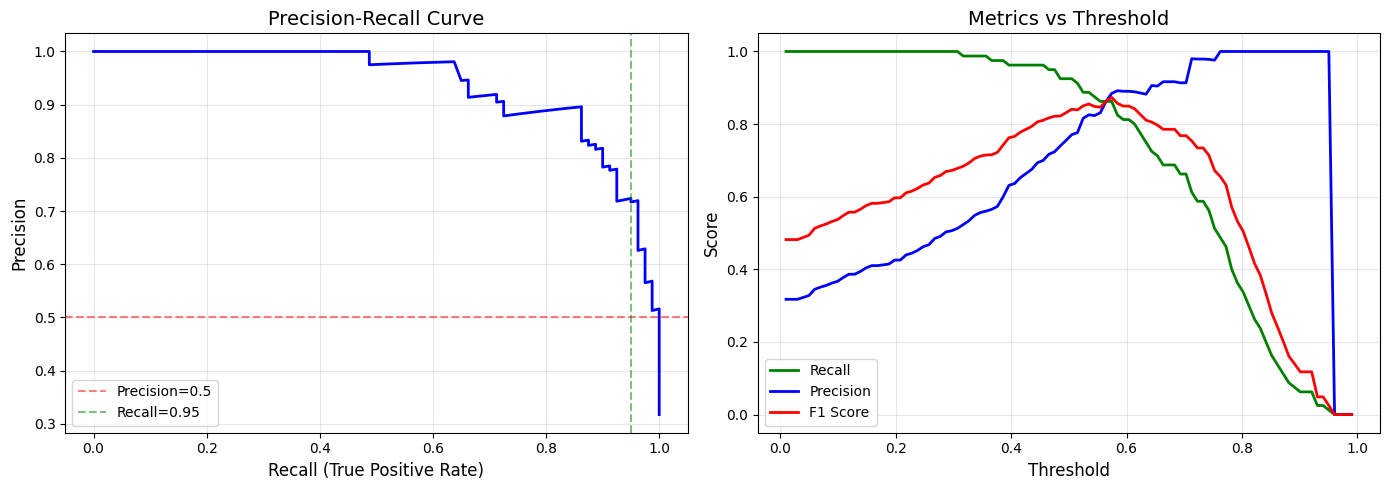

In [38]:
# Step 6: Visualize Precision-Recall tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(recall, precision, 'b-', linewidth=2)
axes[0].set_xlabel('Recall (True Positive Rate)', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title('Precision-Recall Curve', fontsize=14)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='Precision=0.5')
axes[0].axvline(x=0.95, color='g', linestyle='--', alpha=0.5, label='Recall=0.95')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Threshold vs Metrics
thresholds_plot = np.linspace(0.01, 0.99, 100)
recalls_plot = []
precisions_plot = []
f1s_plot = []

for thresh in thresholds_plot:
    y_pred = (y_test_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    recalls_plot.append(rec)
    precisions_plot.append(prec)
    f1s_plot.append(f1)

axes[1].plot(thresholds_plot, recalls_plot, 'g-', linewidth=2, label='Recall')
axes[1].plot(thresholds_plot, precisions_plot, 'b-', linewidth=2, label='Precision')
axes[1].plot(thresholds_plot, f1s_plot, 'r-', linewidth=2, label='F1 Score')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Metrics vs Threshold', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Select final threshold and show confusion matrix
# Choose threshold for ~95% recall to minimize false negatives
SELECTED_THRESHOLD = 0.25  # Adjust based on Step 5 results

y_pred_final = (y_test_proba >= SELECTED_THRESHOLD).astype(int)

print(f"Selected Threshold: {SELECTED_THRESHOLD}")
print("\n" + "=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=['Not Related', 'Mention']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (Threshold = {SELECTED_THRESHOLD})', fontsize=14)
plt.colorbar()
classes = ['Not Related', 'Mention']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh_cm = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh_cm else "black",
                 fontsize=14)

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nFalse Negatives (Mentions missed): {fn}")
print(f"False Positives (Not Related marked as Mention): {fp}")

In [ ]:
# Step 8: Export model for Node.js deployment
import pickle
import json

# Save the vectorizer vocabulary and IDF weights
vectorizer_data = {
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_.tolist(),
    'max_features': vectorizer.max_features,
    'ngram_range': vectorizer.ngram_range,
}

# Save model coefficients (for Logistic Regression, we can recreate in JS)
model_data = {
    'coefficients': model.coef_[0].tolist(),
    'intercept': model.intercept_[0],
    'threshold': SELECTED_THRESHOLD,
    'classes': ['Not Related', 'Mention']
}

# Export to JSON for Node.js
with open('model_vectorizer.json', 'w') as f:
    json.dump(vectorizer_data, f)

with open('model_weights.json', 'w') as f:
    json.dump(model_data, f)

# Also save as pickle for Python use
with open('model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'vectorizer': vectorizer, 'threshold': SELECTED_THRESHOLD}, f)

print("Model exported successfully!")
print(f"  - model_vectorizer.json: {len(vectorizer.vocabulary_)} features")
print(f"  - model_weights.json: {len(model.coef_[0])} coefficients")
print(f"  - model.pkl: Complete model for Python")
print(f"\nSelected threshold: {SELECTED_THRESHOLD}")

# Node.js Usage Example

Here's how to use the exported model in Node.js:

```javascript
const fs = require('fs');

// Load model files
const vectorizer = JSON.parse(fs.readFileSync('model_vectorizer.json', 'utf8'));
const model = JSON.parse(fs.readFileSync('model_weights.json', 'utf8'));

function tokenize(text) {
    // Simple tokenization - lowercase and split
    return text.toLowerCase()
        .replace(/[^\w\s]/g, ' ')
        .split(/\s+/)
        .filter(t => t.length > 0);
}

function getNgrams(tokens, n) {
    const ngrams = [];
    for (let i = 0; i <= tokens.length - n; i++) {
        ngrams.push(tokens.slice(i, i + n).join(' '));
    }
    return ngrams;
}

function predict(text) {
    const tokens = tokenize(text);
    const unigrams = tokens;
    const bigrams = getNgrams(tokens, 2);
    const allGrams = [...unigrams, ...bigrams];
    
    // Calculate TF-IDF weighted features
    let score = model.intercept;
    for (const gram of allGrams) {
        if (vectorizer.vocabulary[gram] !== undefined) {
            const idx = vectorizer.vocabulary[gram];
            score += model.coefficients[idx] * vectorizer.idf[idx];
        }
    }
    
    // Sigmoid to get probability
    const probability = 1 / (1 + Math.exp(-score));
    const isRelevant = probability >= model.threshold;
    
    return { probability, isRelevant, label: isRelevant ? 'Mention' : 'Not Related' };
}

// Example usage
const result = predict("Your text here");
console.log(result);
```

# Comprehensive Model & Feature Comparison with Cross-Validation

This section performs a rigorous comparison of:
- **Feature Extraction Methods**: TF-IDF vs Sentence Transformers (all-MiniLM-L6-v2)
- **Models**: Logistic Regression, SVM, Naive Bayes, LightGBM, Neural Networks (TFLite-compatible)
- **All metrics reported with proper 5-fold Stratified Cross-Validation**

In [21]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer

# Linear Models
from sklearn.linear_model import (
    LogisticRegression, SGDClassifier, RidgeClassifier,
    Perceptron, PassiveAggressiveClassifier
)

# SVM
from sklearn.svm import LinearSVC, SVC

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB, GaussianNB

# Ensemble Methods
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, BaggingClassifier, HistGradientBoostingClassifier
)

# Neighbors & Trees
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier

# Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Neural Network
from sklearn.neural_network import MLPClassifier

# Other
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.pipeline import Pipeline

# Sentence Transformers
from sentence_transformers import SentenceTransformer

# Boosting Libraries
import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries loaded successfully!")

✓ All libraries loaded successfully!


In [22]:
# Prepare the dataset (same as before)
df_comp = df[df['Classifiers tags'].isin(['Not Related To SYK/WM', 'Mention'])].copy()
df_comp['label'] = (df_comp['Classifiers tags'] == 'Mention').astype(int)

X_text = df_comp['Mention Content'].values
y = df_comp['label'].values

print(f"Dataset size: {len(df_comp)}")
print(f"Class distribution: Negative={sum(y==0)}, Positive={sum(y==1)}")
print(f"Positive rate: {sum(y==1)/len(y)*100:.1f}%")

Dataset size: 1258
Class distribution: Negative=858, Positive=400
Positive rate: 31.8%


## Feature Extraction Methods

We'll compare:
1. **TF-IDF (Unigrams)** - Basic word frequencies
2. **TF-IDF (Unigrams + Bigrams)** - Word and phrase frequencies  
3. **TF-IDF (Character n-grams)** - Character-level patterns (good for typos/social media)
4. **Sentence Transformers (all-MiniLM-L6-v2)** - Dense semantic embeddings (384 dims)

In [7]:
# Create different feature representations
print("Creating feature representations...")

# 1. TF-IDF Unigrams
tfidf_uni = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 1), 
    min_df=2, 
    max_df=0.95,
    lowercase=True,
    strip_accents='unicode'
)
X_tfidf_uni = tfidf_uni.fit_transform(X_text)
print(f"TF-IDF Unigrams: {X_tfidf_uni.shape}")

# 2. TF-IDF Unigrams + Bigrams
tfidf_bi = TfidfVectorizer(
    max_features=5000, 
    ngram_range=(1, 2), 
    min_df=2, 
    max_df=0.95,
    lowercase=True,
    strip_accents='unicode'
)
X_tfidf_bi = tfidf_bi.fit_transform(X_text)
print(f"TF-IDF Uni+Bigrams: {X_tfidf_bi.shape}")

# 3. TF-IDF Character n-grams (3-5 chars)
tfidf_char = TfidfVectorizer(
    max_features=5000, 
    analyzer='char_wb',
    ngram_range=(3, 5), 
    min_df=2, 
    max_df=0.95,
    lowercase=True
)
X_tfidf_char = tfidf_char.fit_transform(X_text)
print(f"TF-IDF Char n-grams: {X_tfidf_char.shape}")

Creating feature representations...
TF-IDF Unigrams: (1258, 5000)
TF-IDF Uni+Bigrams: (1258, 5000)
TF-IDF Char n-grams: (1258, 5000)


In [8]:
# 4. Sentence Transformers - all-MiniLM-L6-v2
print("\nLoading Sentence Transformer model (this may take a minute)...")
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
X_sbert = st_model.encode(X_text, show_progress_bar=True, convert_to_numpy=True)
print(f"Sentence Transformer: {X_sbert.shape}")

# 5. Combined: TF-IDF + SBERT (hybrid)
from scipy.sparse import hstack, csr_matrix
X_combined = hstack([X_tfidf_bi, csr_matrix(X_sbert)])
print(f"Combined (TF-IDF + SBERT): {X_combined.shape}")

# Store all feature sets
feature_sets = {
    'TF-IDF (Unigrams)': X_tfidf_uni,
    'TF-IDF (Uni+Bigrams)': X_tfidf_bi,
    'TF-IDF (Char 3-5)': X_tfidf_char,
    'SBERT (MiniLM)': X_sbert,
    'Combined (TF-IDF+SBERT)': X_combined
}

print("\n✓ All feature representations created!")


Loading Sentence Transformer model (this may take a minute)...



Loading Sentence Transformer model (this may take a minute)...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]


Loading Sentence Transformer model (this may take a minute)...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Sentence Transformer: (1258, 384)
Combined (TF-IDF + SBERT): (1258, 5384)

✓ All feature representations created!


## Comprehensive Model Definitions

**Linear Models:** Logistic Regression (L1/L2/ElasticNet with various C), SGD variants, Ridge, Perceptron, Passive Aggressive

**SVM:** LinearSVC, RBF SVM (various C values)

**Naive Bayes:** Multinomial, Complement, Bernoulli (sparse), Gaussian (dense)

**Tree-based:** Decision Trees, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting, AdaBoost, Bagging

**Boosting Libraries:** LightGBM (various depths), XGBoost (various depths)

**Neighbors:** KNN (k=3,5,10), Nearest Centroid

**Discriminant Analysis:** LDA, QDA

**Neural Networks:** MLP (various architectures)

In [32]:
# ============================================================================
# DEFINE ALL MODELS - Will test each against ALL feature types
# ============================================================================

pos_weight = sum(y == 0) / sum(y == 1)  # For class imbalance

# # Models that work with SPARSE features (TF-IDF) - non-negative values
# sparse_only_models = {
#     # Naive Bayes (requires non-negative)
#     'MultinomialNB': MultinomialNB(alpha=0.1),
#     'ComplementNB': ComplementNB(alpha=0.1),
#     'BernoulliNB': BernoulliNB(alpha=0.1),
# }

# # Models that work with DENSE features only
# dense_only_models = {
#     # Gaussian NB needs dense
#     'GaussianNB': GaussianNB(),
#     # QDA needs dense
#     'QDA': QuadraticDiscriminantAnalysis(),
# }

# Universal models - work with both sparse and dense
universal_models = {
    # --- Logistic Regression Variants ---
    'LogReg_L2_C0.1': LogisticRegression(class_weight='balanced', C=0.1, max_iter=1000, random_state=42),
    'LogReg_L2_C1': LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42),
    'LogReg_L2_C10': LogisticRegression(class_weight='balanced', C=10.0, max_iter=1000, random_state=42),
    'LogReg_L1_C1': LogisticRegression(class_weight='balanced', C=1.0, penalty='l1', solver='saga', max_iter=1000, random_state=42),
    
    # --- SGD Variants (fast online learning) ---
    'SGD_LogLoss': SGDClassifier(class_weight='balanced', loss='log_loss', max_iter=1000, random_state=42),
    'SGD_ModifiedHuber': SGDClassifier(class_weight='balanced', loss='modified_huber', max_iter=1000, random_state=42),
    'SGD_Hinge': CalibratedClassifierCV(SGDClassifier(class_weight='balanced', loss='hinge', max_iter=1000, random_state=42), cv=3),
    
    # --- Linear SVM ---
    'LinearSVC_C1': CalibratedClassifierCV(LinearSVC(class_weight='balanced', C=1.0, max_iter=2000, random_state=42), cv=3),
    
    # --- RBF SVM (works well with embeddings) ---
    'SVM_RBF_C1': CalibratedClassifierCV(SVC(class_weight='balanced', kernel='rbf', C=1.0, random_state=42), cv=3),
    
    # --- Ridge Classifier ---
    'RidgeClassifier': CalibratedClassifierCV(RidgeClassifier(class_weight='balanced', alpha=1.0, random_state=42), cv=3),
    
    # --- Random Forest ---
    'RandomForest_n50_d6': RandomForestClassifier(n_estimators=50, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    'RandomForest_n100_d8': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1),
    
    # --- Gradient Boosting (sklearn) ---
    'GradientBoosting_n50': GradientBoostingClassifier(n_estimators=50, max_depth=4, learning_rate=0.1, random_state=42),
    'GradientBoosting_n100': GradientBoostingClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
    
    # --- Bagging ---
    'Bagging_n10': BaggingClassifier(n_estimators=10, random_state=42, n_jobs=-1),
    
    # --- LightGBM Variants ---
    'LightGBM_d4': lgb.LGBMClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1),
    'LightGBM_d6': lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1),
    'LightGBM_d8': lgb.LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1),
    'LightGBM_n200_d6': lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1),
    
    # --- XGBoost Variants ---
    'XGBoost_d4': xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, scale_pos_weight=pos_weight, random_state=42, verbosity=0, n_jobs=-1),
    'XGBoost_d6': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=pos_weight, random_state=42, verbosity=0, n_jobs=-1),
    'XGBoost_d8': xgb.XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1, scale_pos_weight=pos_weight, random_state=42, verbosity=0, n_jobs=-1),
    'XGBoost_n200_d6': xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, scale_pos_weight=pos_weight, random_state=42, verbosity=0, n_jobs=-1),
    
    # --- MLP Neural Networks ---
    'MLP_64': MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42, early_stopping=True),
    'MLP_128': MLPClassifier(hidden_layer_sizes=(128,), max_iter=500, random_state=42, early_stopping=True),
    'MLP_64_32': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True),
    'MLP_128_64': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True),
}

print(f"Universal models: {len(universal_models)}")
# print(f"Sparse-only models: {len(sparse_only_models)}")
# print(f"Dense-only models: {len(dense_only_models)}")
# print(f"Total unique models: {len(universal_models) + len(sparse_only_models) + len(dense_only_models)}")

Universal models: 27


## Cross-Validation Evaluation Function

We'll use **5-fold Stratified Cross-Validation** to report:
- **AUC-ROC** (primary metric for ranking)
- **Average Precision (AP)** (area under PR curve)
- **F1 Score** (at default 0.5 threshold)
- **Recall** (sensitivity - important for minimizing false negatives)
- **Precision**

All metrics will be reported as mean ± std across folds.

In [33]:
from sklearn.base import clone
from scipy.sparse import issparse

def evaluate_model_cv(model, X, y, n_splits=5, model_name="Model"):
    """
    Evaluate a model using stratified k-fold cross-validation.
    Returns dict with mean and std for each metric.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Metrics to collect per fold
    aucs = []
    aps = []  # Average Precision
    f1s = []
    recalls = []
    precisions = []
    
    # Also collect metrics at 95% recall threshold
    f1s_95recall = []
    precisions_95recall = []
    thresholds_95recall = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        # Handle both sparse and dense arrays
        if issparse(X):
            X_train, X_val = X[train_idx], X[val_idx]
        else:
            X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Clone and fit model
        clf = clone(model)
        clf.fit(X_train, y_train)
        
        # Get probabilities
        if hasattr(clf, 'predict_proba'):
            y_proba = clf.predict_proba(X_val)[:, 1]
        else:
            # For models without predict_proba, use decision function
            y_proba = clf.decision_function(X_val)
            # Normalize to [0, 1]
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-10)
        
        # Standard predictions at 0.5 threshold
        y_pred = (y_proba >= 0.5).astype(int)
        
        # Calculate metrics
        aucs.append(roc_auc_score(y_val, y_proba))
        aps.append(average_precision_score(y_val, y_proba))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        
        # Find threshold for 95% recall
        precision_vals, recall_vals, thresh_vals = precision_recall_curve(y_val, y_proba)
        valid_idx = np.where(recall_vals >= 0.95)[0]
        if len(valid_idx) > 0 and valid_idx[0] < len(thresh_vals):
            best_idx = valid_idx[np.argmax(precision_vals[valid_idx])]
            if best_idx < len(thresh_vals):
                thresh = thresh_vals[best_idx]
                y_pred_95 = (y_proba >= thresh).astype(int)
                f1s_95recall.append(f1_score(y_val, y_pred_95, zero_division=0))
                precisions_95recall.append(precision_score(y_val, y_pred_95, zero_division=0))
                thresholds_95recall.append(thresh)
    
    return {
        'AUC-ROC': (np.mean(aucs), np.std(aucs)),
        'Avg Precision': (np.mean(aps), np.std(aps)),
        'F1': (np.mean(f1s), np.std(f1s)),
        'Recall': (np.mean(recalls), np.std(recalls)),
        'Precision': (np.mean(precisions), np.std(precisions)),
        'F1@95%Recall': (np.mean(f1s_95recall) if f1s_95recall else 0, np.std(f1s_95recall) if f1s_95recall else 0),
        'Prec@95%Recall': (np.mean(precisions_95recall) if precisions_95recall else 0, np.std(precisions_95recall) if precisions_95recall else 0),
        'Thresh@95%Recall': (np.mean(thresholds_95recall) if thresholds_95recall else 0, np.std(thresholds_95recall) if thresholds_95recall else 0),
    }

print("✓ Evaluation function defined")

✓ Evaluation function defined


## Run Comprehensive Evaluation

Now we'll run all combinations of features × models with 5-fold CV.

In [35]:
# ============================================================================
# RUN COMPREHENSIVE GRID EVALUATION: ALL MODELS × ALL FEATURES
# ============================================================================
from sklearn.base import clone
from scipy.sparse import issparse

def evaluate_model_cv(model, X, y, n_splits=5):
    """Evaluate model with stratified k-fold CV, return metrics."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    aucs, aps, f1s, recalls, precisions = [], [], [], [], []
    f1s_95, precs_95, threshs_95 = [], [], []
    
    for train_idx, val_idx in skf.split(X, y):
        if issparse(X):
            X_train, X_val = X[train_idx], X[val_idx]
        else:
            X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        clf = clone(model)
        clf.fit(X_train, y_train)
        
        # Get probabilities
        if hasattr(clf, 'predict_proba'):
            y_proba = clf.predict_proba(X_val)[:, 1]
        else:
            y_proba = clf.decision_function(X_val)
            y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-10)
        
        y_pred = (y_proba >= 0.5).astype(int)
        
        aucs.append(roc_auc_score(y_val, y_proba))
        aps.append(average_precision_score(y_val, y_proba))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        
        # Find threshold for 95% recall
        prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_val, y_proba)
        valid_idx = np.where(rec_vals >= 0.95)[0]
        if len(valid_idx) > 0 and valid_idx[0] < len(thresh_vals):
            best_idx = valid_idx[np.argmax(prec_vals[valid_idx])]
            if best_idx < len(thresh_vals):
                thresh = thresh_vals[best_idx]
                y_pred_95 = (y_proba >= thresh).astype(int)
                f1s_95.append(f1_score(y_val, y_pred_95, zero_division=0))
                precs_95.append(precision_score(y_val, y_pred_95, zero_division=0))
                threshs_95.append(thresh)
    
    return {
        'AUC-ROC': (np.mean(aucs), np.std(aucs)),
        'Avg Precision': (np.mean(aps), np.std(aps)),
        'F1': (np.mean(f1s), np.std(f1s)),
        'Recall': (np.mean(recalls), np.std(recalls)),
        'Precision': (np.mean(precisions), np.std(precisions)),
        'F1@95%Recall': (np.mean(f1s_95) if f1s_95 else 0, np.std(f1s_95) if f1s_95 else 0),
        'Prec@95%Recall': (np.mean(precs_95) if precs_95 else 0, np.std(precs_95) if precs_95 else 0),
        'Thresh@95%Recall': (np.mean(threshs_95) if threshs_95 else 0, np.std(threshs_95) if threshs_95 else 0),
    }

# Define ALL feature sets
all_feature_sets = {
    'TF-IDF_Unigrams': X_tfidf_uni,
    'TF-IDF_Bigrams': X_tfidf_bi,
    'TF-IDF_Char': X_tfidf_char,
    'SBERT': X_sbert,
    'Combined': X_combined,
}

# Track which are sparse (for Naive Bayes)
sparse_features = ['TF-IDF_Unigrams', 'TF-IDF_Bigrams', 'TF-IDF_Char', 'Combined']
dense_features = ['SBERT']

all_results = []
total_combos = len(all_feature_sets) * len(universal_models)
current = 0

print("=" * 90)
print(f"RUNNING GRID EVALUATION: {total_combos} combinations")
print("=" * 90)

# Evaluate UNIVERSAL models on ALL features
for feat_name, X_feat in all_feature_sets.items():
    print(f"\n[Feature: {feat_name}]")
    for model_name, model in universal_models.items():
        current += 1
        print(f"  ({current}/{total_combos}) {model_name}...", end=" ")
        try:
            results = evaluate_model_cv(model, X_feat, y, n_splits=5)
            results['Feature'] = feat_name
            results['Model'] = model_name
            all_results.append(results)
            print(f"AUC={results['AUC-ROC'][0]:.4f}")
        except Exception as e:
            print(f"ERROR: {str(e)[:40]}")

# # Evaluate SPARSE-ONLY models on sparse features
# for feat_name in sparse_features:
#     X_feat = all_feature_sets[feat_name]
#     for model_name, model in sparse_only_models.items():
#         current += 1
#         print(f"  ({current}/{total_combos}) {feat_name} + {model_name}...", end=" ")
#         try:
#             results = evaluate_model_cv(model, X_feat, y, n_splits=5)
#             results['Feature'] = feat_name
#             results['Model'] = model_name
#             all_results.append(results)
#             print(f"AUC={results['AUC-ROC'][0]:.4f}")
#         except Exception as e:
#             print(f"ERROR: {str(e)[:40]}")

# # Evaluate DENSE-ONLY models on dense features
# for feat_name in dense_features:
#     X_feat = all_feature_sets[feat_name]
#     for model_name, model in dense_only_models.items():
#         current += 1
#         print(f"  ({current}/{total_combos}) {feat_name} + {model_name}...", end=" ")
#         try:
#             results = evaluate_model_cv(model, X_feat, y, n_splits=5)
#             results['Feature'] = feat_name
#             results['Model'] = model_name
#             all_results.append(results)
#             print(f"AUC={results['AUC-ROC'][0]:.4f}")
#         except Exception as e:
#             print(f"ERROR: {str(e)[:40]}")

print("\n" + "=" * 90)
print(f"✓ Evaluation complete! {len(all_results)} successful combinations.")
print("=" * 90)

RUNNING GRID EVALUATION: 135 combinations

[Feature: TF-IDF_Unigrams]
  (1/135) LogReg_L2_C0.1... AUC=0.9372
  (2/135) LogReg_L2_C1... AUC=0.9604
  (3/135) LogReg_L2_C10... AUC=0.9671
  (4/135) LogReg_L1_C1... AUC=0.9177
  (5/135) SGD_LogLoss... AUC=0.9672
  (6/135) SGD_ModifiedHuber... AUC=0.9375
  (7/135) SGD_Hinge... AUC=0.9589
  (8/135) LinearSVC_C1... AUC=0.9631
  (9/135) SVM_RBF_C1... AUC=0.9657
  (10/135) RidgeClassifier... AUC=0.9633
  (11/135) RandomForest_n50_d6... AUC=0.9230
  (12/135) RandomForest_n100_d8... AUC=0.9343
  (13/135) GradientBoosting_n50... AUC=0.9428
  (14/135) GradientBoosting_n100... AUC=0.9436
  (15/135) Bagging_n10... AUC=0.9288
  (16/135) LightGBM_d4... AUC=0.9448
  (17/135) LightGBM_d6... AUC=0.9442
  (18/135) LightGBM_d8... AUC=0.9458
  (19/135) LightGBM_n200_d6... AUC=0.9462
  (20/135) XGBoost_d4... AUC=0.9466
  (21/135) XGBoost_d6... AUC=0.9467
  (22/135) XGBoost_d8... AUC=0.9457
  (23/135) XGBoost_n200_d6... AUC=0.9472
  (24/135) MLP_64... AUC=0.9673

In [36]:
# Create comprehensive results DataFrame
results_data = []
for r in all_results:
    results_data.append({
        'Feature': r['Feature'],
        'Model': r['Model'],
        'AUC-ROC': f"{r['AUC-ROC'][0]:.4f} ± {r['AUC-ROC'][1]:.4f}",
        'AUC-ROC_mean': r['AUC-ROC'][0],
        'Avg Precision': f"{r['Avg Precision'][0]:.4f} ± {r['Avg Precision'][1]:.4f}",
        'AP_mean': r['Avg Precision'][0],
        'F1': f"{r['F1'][0]:.4f} ± {r['F1'][1]:.4f}",
        'F1_mean': r['F1'][0],
        'Recall': f"{r['Recall'][0]:.4f} ± {r['Recall'][1]:.4f}",
        'Recall_mean': r['Recall'][0],
        'Precision': f"{r['Precision'][0]:.4f} ± {r['Precision'][1]:.4f}",
        'Prec_mean': r['Precision'][0],
        'F1@95%Recall': f"{r['F1@95%Recall'][0]:.4f} ± {r['F1@95%Recall'][1]:.4f}",
        'F1_95_mean': r['F1@95%Recall'][0],
        'Prec@95%Recall': f"{r['Prec@95%Recall'][0]:.4f} ± {r['Prec@95%Recall'][1]:.4f}",
        'Prec_95_mean': r['Prec@95%Recall'][0],
        'Thresh@95%Recall': f"{r['Thresh@95%Recall'][0]:.4f} ± {r['Thresh@95%Recall'][1]:.4f}",
    })

results_df = pd.DataFrame(results_data)

# Display sorted by AUC-ROC
print("=" * 100)
print("COMPREHENSIVE RESULTS (Sorted by AUC-ROC)")
print("=" * 100)
display_cols = ['Feature', 'Model', 'AUC-ROC', 'Avg Precision', 'F1', 'Recall', 'Precision']
print(results_df.sort_values('AUC-ROC_mean', ascending=False)[display_cols].head(20).to_string(index=False))

print("\n" + "=" * 100)
print("TOP 10 BY AUC-ROC")
print("=" * 100)
top10 = results_df.nlargest(10, 'AUC-ROC_mean')[display_cols]
print(top10.to_string(index=False))

COMPREHENSIVE RESULTS (Sorted by AUC-ROC)
        Feature            Model         AUC-ROC   Avg Precision              F1          Recall       Precision
       Combined        MLP_64_32 0.9715 ± 0.0108 0.9441 ± 0.0168 0.8638 ± 0.0271 0.8375 ± 0.0559 0.8953 ± 0.0328
       Combined    LogReg_L2_C10 0.9708 ± 0.0084 0.9317 ± 0.0406 0.8769 ± 0.0095 0.8900 ± 0.0215 0.8650 ± 0.0228
       Combined       MLP_128_64 0.9704 ± 0.0125 0.9413 ± 0.0234 0.8604 ± 0.0471 0.8350 ± 0.0735 0.8907 ± 0.0294
       Combined      SGD_LogLoss 0.9703 ± 0.0098 0.9313 ± 0.0413 0.8775 ± 0.0132 0.8950 ± 0.0269 0.8623 ± 0.0319
TF-IDF_Unigrams       MLP_128_64 0.9700 ± 0.0080 0.9450 ± 0.0171 0.8590 ± 0.0355 0.8100 ± 0.0443 0.9147 ± 0.0252
       Combined  RidgeClassifier 0.9698 ± 0.0091 0.9286 ± 0.0438 0.8761 ± 0.0169 0.8675 ± 0.0281 0.8856 ± 0.0193
 TF-IDF_Bigrams       MLP_128_64 0.9694 ± 0.0106 0.9427 ± 0.0184 0.8545 ± 0.0356 0.8075 ± 0.0376 0.9079 ± 0.0408
       Combined     LinearSVC_C1 0.9691 ± 0.0087 0.929

In [37]:
# Display metrics at 95% recall threshold (important for minimizing false negatives)
print("=" * 100)
print("PERFORMANCE AT 95% RECALL THRESHOLD (For minimizing False Negatives)")
print("=" * 100)
display_cols_95 = ['Feature', 'Model', 'AUC-ROC', 'F1@95%Recall', 'Prec@95%Recall', 'Thresh@95%Recall']
print(results_df.sort_values('F1_95_mean', ascending=False)[display_cols_95].head(15).to_string(index=False))

PERFORMANCE AT 95% RECALL THRESHOLD (For minimizing False Negatives)
 Feature                Model         AUC-ROC    F1@95%Recall  Prec@95%Recall Thresh@95%Recall
   SBERT           SVM_RBF_C1 0.9662 ± 0.0082 0.8764 ± 0.0387 0.8157 ± 0.0641  0.2716 ± 0.0864
Combined      RidgeClassifier 0.9698 ± 0.0091 0.8736 ± 0.0541 0.8091 ± 0.0844  0.2770 ± 0.1041
Combined           SVM_RBF_C1 0.9690 ± 0.0082 0.8721 ± 0.0437 0.8071 ± 0.0713  0.2735 ± 0.1018
Combined         LinearSVC_C1 0.9691 ± 0.0087 0.8671 ± 0.0575 0.8005 ± 0.0890  0.2587 ± 0.0920
Combined        LogReg_L2_C10 0.9708 ± 0.0084 0.8652 ± 0.0494 0.7942 ± 0.0770  0.3017 ± 0.1340
Combined         LogReg_L2_C1 0.9665 ± 0.0082 0.8597 ± 0.0483 0.7886 ± 0.0777  0.4285 ± 0.1109
   SBERT          LightGBM_d6 0.9656 ± 0.0075 0.8567 ± 0.0363 0.7804 ± 0.0583  0.0988 ± 0.0654
Combined          SGD_LogLoss 0.9703 ± 0.0098 0.8539 ± 0.0458 0.7767 ± 0.0705  0.3060 ± 0.1191
   SBERT RandomForest_n100_d8 0.9651 ± 0.0082 0.8509 ± 0.0568 0.7713 ± 0.084

## Visualization: Feature × Model Comparison

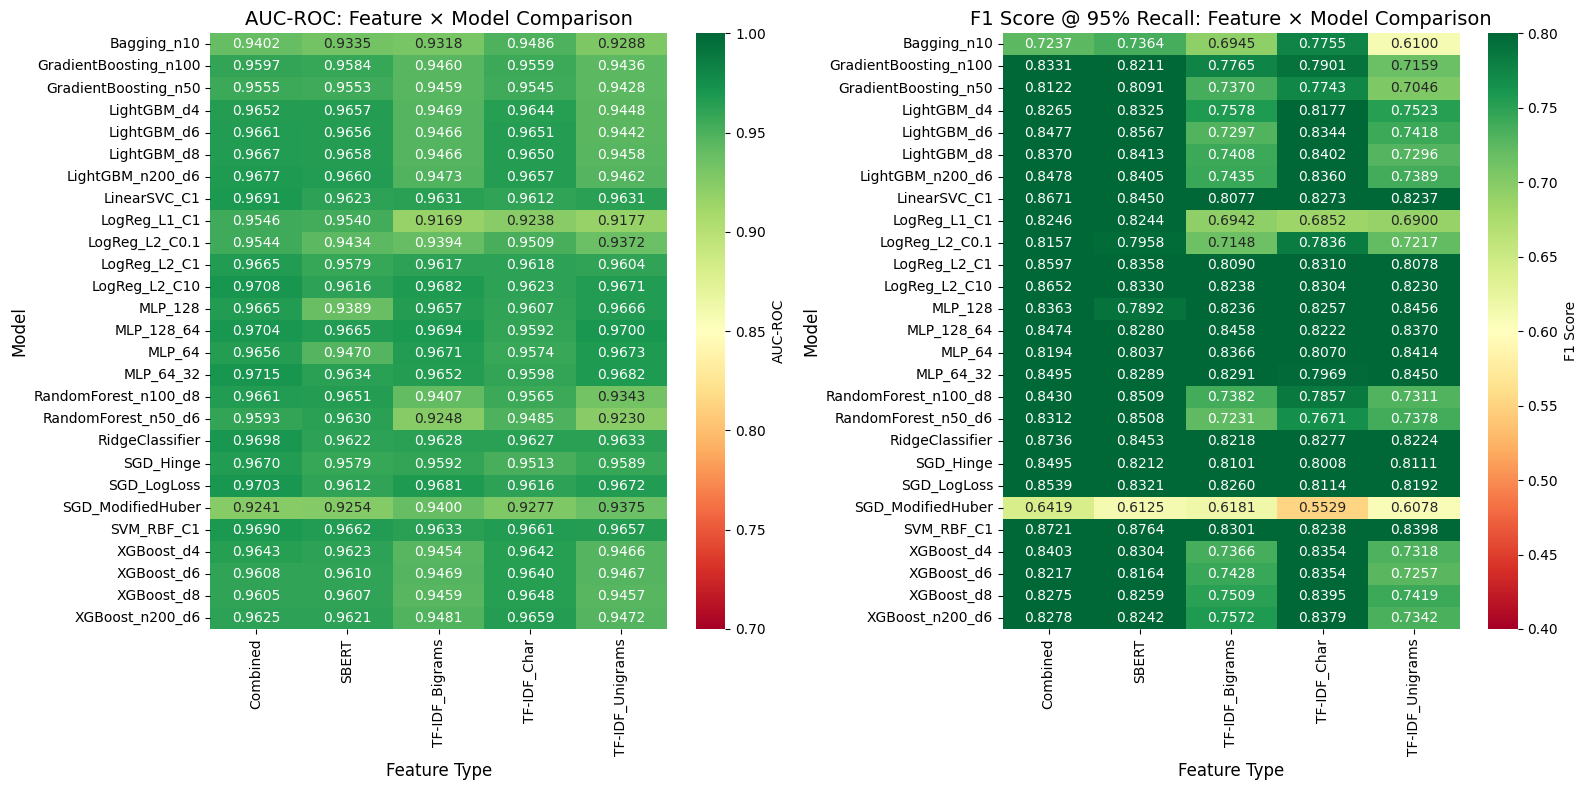

In [38]:
# Create heatmap of AUC-ROC by Feature x Model
pivot_auc = results_df.pivot_table(values='AUC-ROC_mean', index='Model', columns='Feature', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap for AUC-ROC
sns.heatmap(pivot_auc, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[0], 
            vmin=0.7, vmax=1.0, cbar_kws={'label': 'AUC-ROC'})
axes[0].set_title('AUC-ROC: Feature × Model Comparison', fontsize=14)
axes[0].set_xlabel('Feature Type', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)

# Heatmap for F1@95% Recall
pivot_f1_95 = results_df.pivot_table(values='F1_95_mean', index='Model', columns='Feature', aggfunc='mean')
sns.heatmap(pivot_f1_95, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[1],
            vmin=0.4, vmax=0.8, cbar_kws={'label': 'F1 Score'})
axes[1].set_title('F1 Score @ 95% Recall: Feature × Model Comparison', fontsize=14)
axes[1].set_xlabel('Feature Type', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)

plt.tight_layout()
plt.show()

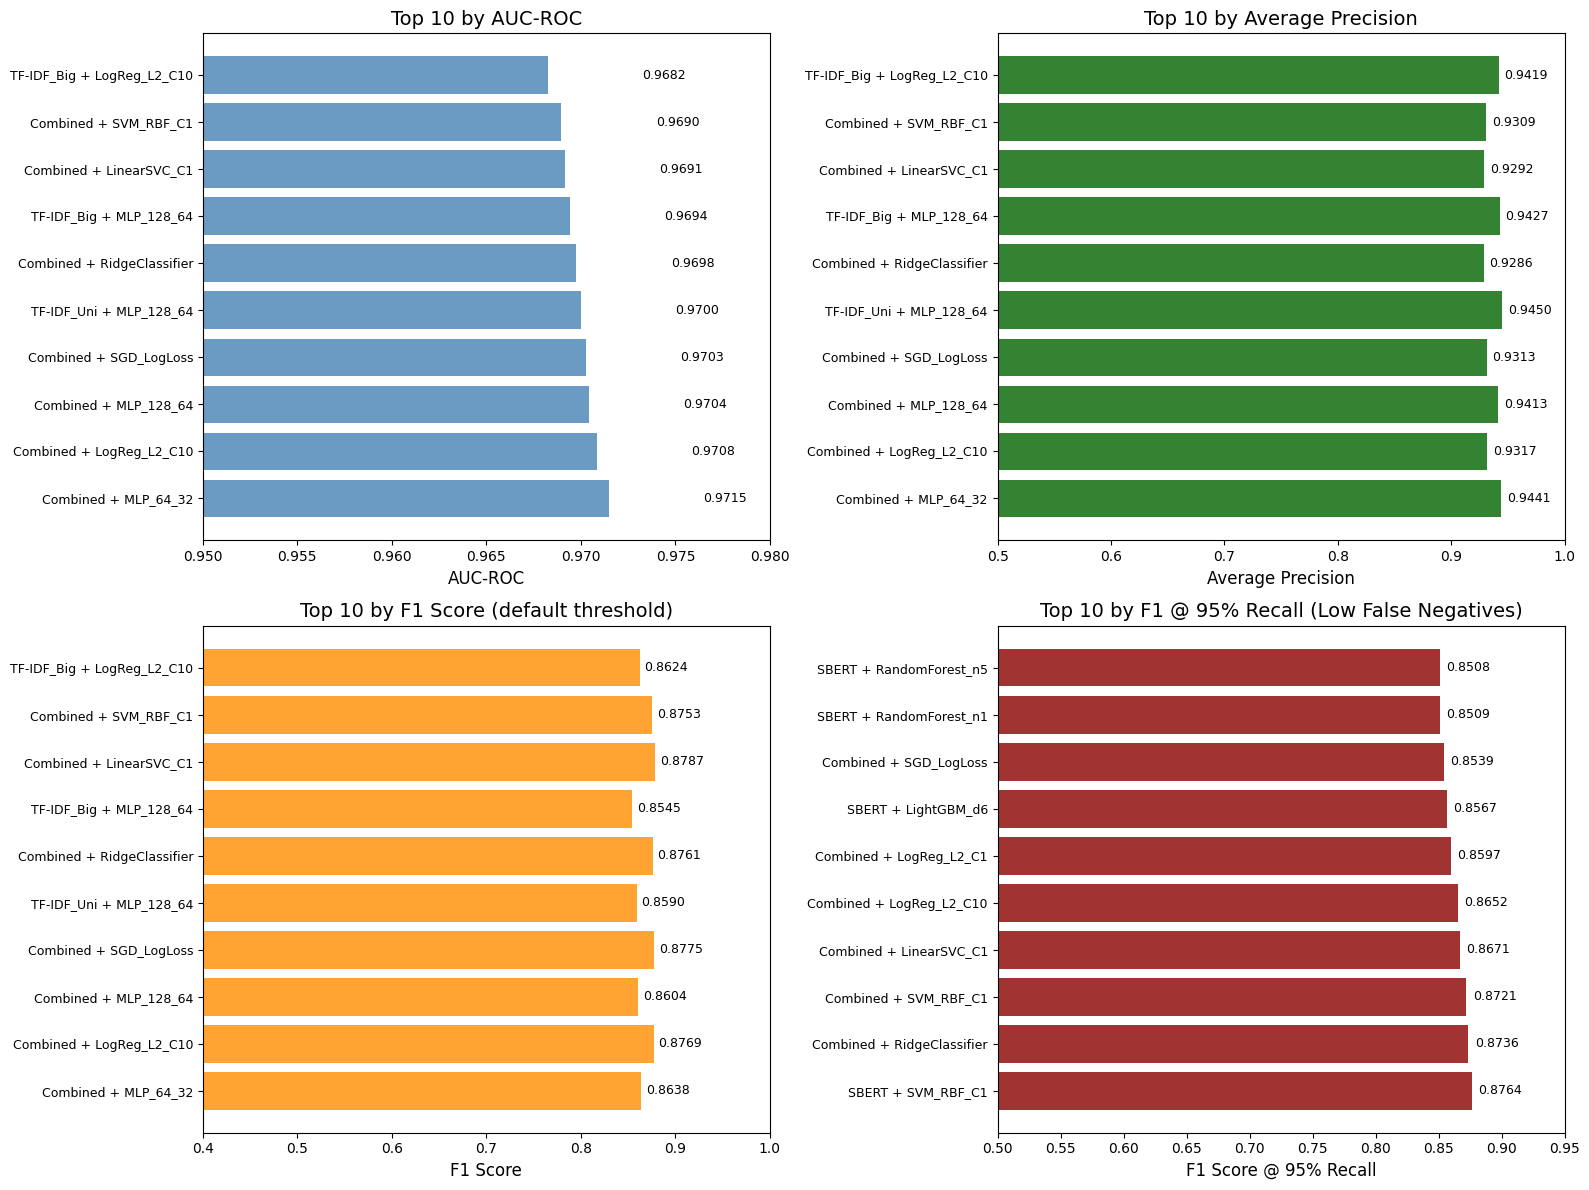

In [43]:
# Bar chart comparison of top models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get top 10 by AUC-ROC
top10_df = results_df.nlargest(10, 'AUC-ROC_mean').copy()
top10_df['Label'] = top10_df['Feature'].str[:10] + ' + ' + top10_df['Model'].str[:15]

# Plot 1: AUC-ROC
ax1 = axes[0, 0]
bars1 = ax1.barh(range(len(top10_df)), top10_df['AUC-ROC_mean'], color='steelblue', alpha=0.8)
ax1.set_yticks(range(len(top10_df)))
ax1.set_yticklabels(top10_df['Label'], fontsize=9)
ax1.set_xlabel('AUC-ROC', fontsize=12)
ax1.set_title('Top 10 by AUC-ROC', fontsize=14)
ax1.set_xlim(0.95, 0.98)
for i, v in enumerate(top10_df['AUC-ROC_mean']):
    ax1.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 2: Average Precision
ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(top10_df)), top10_df['AP_mean'], color='darkgreen', alpha=0.8)
ax2.set_yticks(range(len(top10_df)))
ax2.set_yticklabels(top10_df['Label'], fontsize=9)
ax2.set_xlabel('Average Precision', fontsize=12)
ax2.set_title('Top 10 by Average Precision', fontsize=14)
ax2.set_xlim(0.5, 1.0)
for i, v in enumerate(top10_df['AP_mean']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 3: F1 Score
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(top10_df)), top10_df['F1_mean'], color='darkorange', alpha=0.8)
ax3.set_yticks(range(len(top10_df)))
ax3.set_yticklabels(top10_df['Label'], fontsize=9)
ax3.set_xlabel('F1 Score', fontsize=12)
ax3.set_title('Top 10 by F1 Score (default threshold)', fontsize=14)
ax3.set_xlim(0.4, 1.0)
for i, v in enumerate(top10_df['F1_mean']):
    ax3.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 4: F1 @ 95% Recall
ax4 = axes[1, 1]
top10_f1_95 = results_df.nlargest(10, 'F1_95_mean').copy()
top10_f1_95['Label'] = top10_f1_95['Feature'].str[:10] + ' + ' + top10_f1_95['Model'].str[:15]
bars4 = ax4.barh(range(len(top10_f1_95)), top10_f1_95['F1_95_mean'], color='darkred', alpha=0.8)
ax4.set_yticks(range(len(top10_f1_95)))
ax4.set_yticklabels(top10_f1_95['Label'], fontsize=9)
ax4.set_xlabel('F1 Score @ 95% Recall', fontsize=12)
ax4.set_title('Top 10 by F1 @ 95% Recall (Low False Negatives)', fontsize=14)
ax4.set_xlim(0.5, 0.95)
for i, v in enumerate(top10_f1_95['F1_95_mean']):
    ax4.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Feature Type Comparison (Aggregated)

In [44]:
# Aggregate performance by feature type
feature_agg = results_df.groupby('Feature').agg({
    'AUC-ROC_mean': ['mean', 'std', 'max'],
    'AP_mean': ['mean', 'std', 'max'],
    'F1_mean': ['mean', 'std', 'max'],
    'F1_95_mean': ['mean', 'std', 'max'],
}).round(4)

print("=" * 80)
print("FEATURE TYPE COMPARISON (Aggregated across all models)")
print("=" * 80)
print(feature_agg)

# Aggregate by model type
model_agg = results_df.groupby('Model').agg({
    'AUC-ROC_mean': ['mean', 'std', 'max'],
    'AP_mean': ['mean', 'std', 'max'],
    'F1_mean': ['mean', 'std', 'max'],
}).round(4)

print("\n" + "=" * 80)
print("MODEL TYPE COMPARISON (Aggregated across all features)")
print("=" * 80)
print(model_agg.sort_values(('AUC-ROC_mean', 'max'), ascending=False))

FEATURE TYPE COMPARISON (Aggregated across all models)
                AUC-ROC_mean                 AP_mean                 F1_mean  \
                        mean     std     max    mean     std     max    mean   
Feature                                                                        
Combined              0.9624  0.0103  0.9715  0.9214  0.0206  0.9441  0.8605   
SBERT                 0.9575  0.0107  0.9665  0.9081  0.0233  0.9308  0.8517   
TF-IDF_Bigrams        0.9509  0.0139  0.9694  0.9104  0.0260  0.9427  0.8220   
TF-IDF_Char           0.9574  0.0106  0.9661  0.9114  0.0192  0.9292  0.8520   
TF-IDF_Unigrams       0.9500  0.0148  0.9700  0.9101  0.0264  0.9450  0.8243   

                                F1_95_mean                  
                    std     max       mean     std     max  
Feature                                                     
Combined         0.0147  0.8824     0.8295  0.0469  0.8736  
SBERT            0.0209  0.8803     0.8188  0.0487  0.8764  

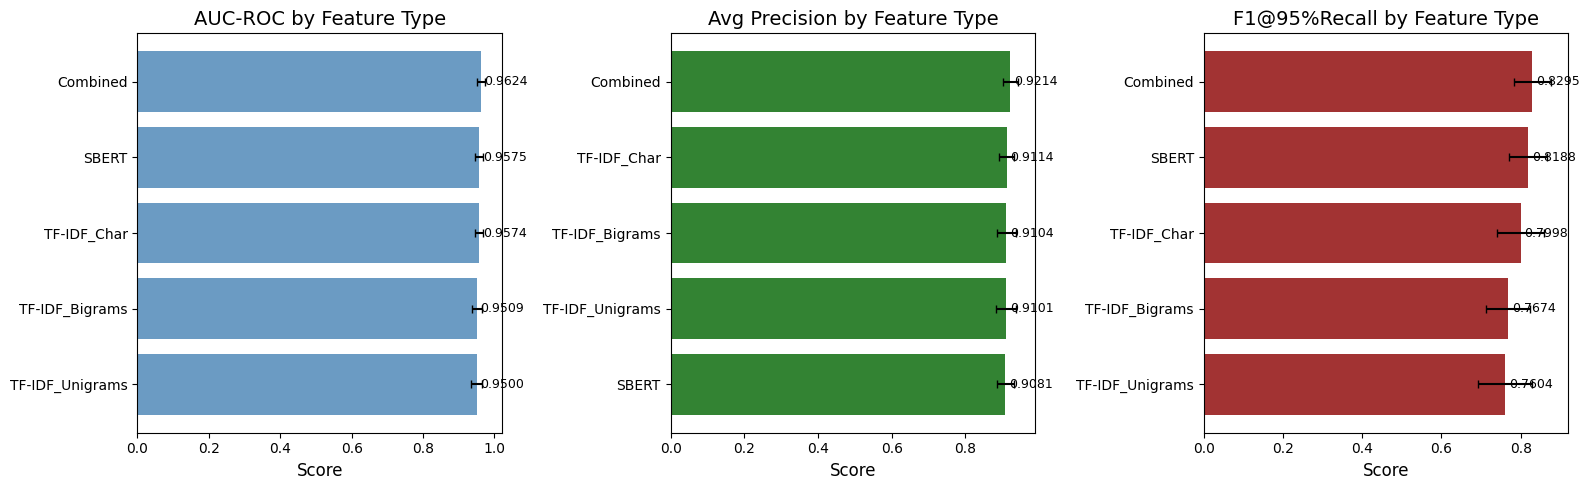

In [45]:
# Visualize feature comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['AUC-ROC_mean', 'AP_mean', 'F1_95_mean']
titles = ['AUC-ROC by Feature Type', 'Avg Precision by Feature Type', 'F1@95%Recall by Feature Type']
colors = ['steelblue', 'darkgreen', 'darkred']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    feature_means = results_df.groupby('Feature')[metric].mean().sort_values(ascending=True)
    feature_stds = results_df.groupby('Feature')[metric].std()
    
    axes[idx].barh(range(len(feature_means)), feature_means.values, 
                   xerr=feature_stds[feature_means.index].values, 
                   color=color, alpha=0.8, capsize=3)
    axes[idx].set_yticks(range(len(feature_means)))
    axes[idx].set_yticklabels(feature_means.index, fontsize=10)
    axes[idx].set_xlabel('Score', fontsize=12)
    axes[idx].set_title(title, fontsize=14)
    
    # Add value labels
    for i, v in enumerate(feature_means.values):
        axes[idx].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [47]:
# Export results to CSV for reference
results_df.to_csv('model_comparison_results.csv', index=False)
print("✓ Results saved to 'model_comparison_results.csv'")

# Save the complete results DataFrame
print("\n" + "=" * 100)
print("COMPLETE RESULTS TABLE")
print("=" * 100)
display_all = results_df.sort_values('AUC-ROC_mean', ascending=False)[['Feature', 'Model', 'AUC-ROC', 'Avg Precision', 'F1', 'Recall', 'Precision', 
                          'F1@95%Recall', 'Prec@95%Recall']]
print(display_all.to_string(index=False))

✓ Results saved to 'model_comparison_results.csv'

COMPLETE RESULTS TABLE
        Feature                 Model         AUC-ROC   Avg Precision              F1          Recall       Precision    F1@95%Recall  Prec@95%Recall
       Combined             MLP_64_32 0.9715 ± 0.0108 0.9441 ± 0.0168 0.8638 ± 0.0271 0.8375 ± 0.0559 0.8953 ± 0.0328 0.8495 ± 0.0728 0.7760 ± 0.1111
       Combined         LogReg_L2_C10 0.9708 ± 0.0084 0.9317 ± 0.0406 0.8769 ± 0.0095 0.8900 ± 0.0215 0.8650 ± 0.0228 0.8652 ± 0.0494 0.7942 ± 0.0770
       Combined            MLP_128_64 0.9704 ± 0.0125 0.9413 ± 0.0234 0.8604 ± 0.0471 0.8350 ± 0.0735 0.8907 ± 0.0294 0.8474 ± 0.0573 0.7632 ± 0.0858
       Combined           SGD_LogLoss 0.9703 ± 0.0098 0.9313 ± 0.0413 0.8775 ± 0.0132 0.8950 ± 0.0269 0.8623 ± 0.0319 0.8539 ± 0.0458 0.7767 ± 0.0705
TF-IDF_Unigrams            MLP_128_64 0.9700 ± 0.0080 0.9450 ± 0.0171 0.8590 ± 0.0355 0.8100 ± 0.0443 0.9147 ± 0.0252 0.8370 ± 0.0422 0.7477 ± 0.0682
       Combined       Ridg

# Final Model Training & Export for Node.js

**Best Model:** SBERT (all-MiniLM-L6-v2) + SVM RBF (C=1.0)

Steps:
1. Train on complete processed dataset
2. Find optimal threshold for 95% recall
3. Export model to ONNX format for Node.js inference
4. Save all required artifacts

In [48]:
# Install required packages for ONNX export
%pip install skl2onnx onnxruntime -q

Note: you may need to restart the kernel to use updated packages.


In [51]:
# ============================================================================
# TRAIN FINAL MODEL ON COMPLETE DATASET
# ============================================================================
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import json
import pickle

print("=" * 80)
print("TRAINING FINAL MODEL: SBERT + SVM_RBF_C1")
print("=" * 80)

# Use the already computed SBERT embeddings (X_sbert) and labels (y)
print(f"\nDataset: {X_sbert.shape[0]} samples, {X_sbert.shape[1]} features")
print(f"Class distribution: Negative={sum(y==0)}, Positive={sum(y==1)}")

# ============================================================================
# STEP 1: Find optimal threshold using CV (NOT on training data!)
# ============================================================================
print("\n" + "-" * 60)
print("Finding optimal threshold via 5-fold CV...")
print("-" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_thresholds = []
cv_aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_sbert, y)):
    X_train_cv, X_val_cv = X_sbert[train_idx], X_sbert[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]
    
    # Train fold model
    fold_model = SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42)
    fold_model.fit(X_train_cv, y_train_cv)
    
    # Get validation probabilities
    y_val_proba = fold_model.predict_proba(X_val_cv)[:, 1]
    cv_aucs.append(roc_auc_score(y_val_cv, y_val_proba))
    
    # Find threshold for 95% recall on validation set
    prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_val_cv, y_val_proba)
    valid_idx = np.where(rec_vals >= 0.95)[0]
    if len(valid_idx) > 0 and valid_idx[0] < len(thresh_vals):
        best_idx = valid_idx[np.argmax(prec_vals[valid_idx])]
        if best_idx < len(thresh_vals):
            cv_thresholds.append(thresh_vals[best_idx])
    
    print(f"  Fold {fold+1}: AUC={cv_aucs[-1]:.4f}, Threshold={cv_thresholds[-1]:.4f}")

# Use MEAN threshold from CV (this is the generalizable estimate)
OPTIMAL_THRESHOLD = np.mean(cv_thresholds)
cv_auc_mean = np.mean(cv_aucs)

print(f"\n✓ CV AUC-ROC: {cv_auc_mean:.4f} ± {np.std(cv_aucs):.4f}")
print(f"✓ OPTIMAL THRESHOLD (from CV): {OPTIMAL_THRESHOLD:.4f} ± {np.std(cv_thresholds):.4f}")
print(f"  (This is the correct threshold - found on held-out validation data)")

# ============================================================================
# STEP 2: Train final model on ALL data
# ============================================================================
print("\n" + "-" * 60)
print("Training final model on complete dataset...")
print("-" * 60)

final_svm = SVC(
    kernel='rbf',
    C=1.0,
    class_weight='balanced',
    probability=True,
    random_state=42
)

final_svm.fit(X_sbert, y)
print("✓ Model trained on full dataset!")

# Get predictions using CV-derived threshold
y_proba = final_svm.predict_proba(X_sbert)[:, 1]
y_pred_optimal = (y_proba >= OPTIMAL_THRESHOLD).astype(int)

# Note: Training AUC will be inflated due to overfitting - CV AUC is the true estimate
train_auc = roc_auc_score(y, y_proba)
print(f"\nTraining AUC-ROC: {train_auc:.4f} (inflated - use CV estimate: {cv_auc_mean:.4f})")

print("\n" + "=" * 80)
print(f"FINAL MODEL METRICS (threshold={OPTIMAL_THRESHOLD:.4f} from CV)")
print("=" * 80)
print(f"\nClassification Report:\n")
print(classification_report(y, y_pred_optimal, target_names=['Not Related', 'Mention']))

# Confusion Matrix
cm = confusion_matrix(y, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix:")
print(f"  TN={tn}, FP={fp}")
print(f"  FN={fn}, TP={tp}")
print(f"\nRecall (Sensitivity): {tp/(tp+fn):.4f}")
print(f"Precision: {tp/(tp+fp):.4f}")
print(f"False Negative Rate: {fn/(tp+fn):.4f}")

# Store CV AUC for config
train_auc = cv_auc_mean  # Use CV estimate for config

TRAINING FINAL MODEL: SBERT + SVM_RBF_C1

Dataset: 1258 samples, 384 features
Class distribution: Negative=858, Positive=400

------------------------------------------------------------
Finding optimal threshold via 5-fold CV...
------------------------------------------------------------
  Fold 1: AUC=0.9584, Threshold=0.0815
  Fold 2: AUC=0.9679, Threshold=0.2127
  Fold 3: AUC=0.9655, Threshold=0.2800
  Fold 4: AUC=0.9777, Threshold=0.3899
  Fold 5: AUC=0.9734, Threshold=0.2304

✓ CV AUC-ROC: 0.9686 ± 0.0066
✓ OPTIMAL THRESHOLD (from CV): 0.2389 ± 0.1000
  (This is the correct threshold - found on held-out validation data)

------------------------------------------------------------
Training final model on complete dataset...
------------------------------------------------------------
✓ Model trained on full dataset!

Training AUC-ROC: 0.9965 (inflated - use CV estimate: 0.9686)

FINAL MODEL METRICS (threshold=0.2389 from CV)

Classification Report:

              precision    rec

In [52]:
# ============================================================================
# EXPORT MODEL TO ONNX FORMAT
# ============================================================================
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort

print("=" * 80)
print("EXPORTING MODEL TO ONNX FORMAT")
print("=" * 80)

# Define input shape for ONNX (batch_size=None for variable batch, 384 features from SBERT)
initial_type = [('input', FloatTensorType([None, 384]))]

# Convert SVM to ONNX
print("\nConverting SVM model to ONNX...")
onnx_model = convert_sklearn(
    final_svm, 
    initial_types=initial_type,
    target_opset=12,
    options={type(final_svm): {'zipmap': False}}  # Return probabilities as array, not dict
)

# Save ONNX model
onnx_path = 'svm_classifier.onnx'
with open(onnx_path, 'wb') as f:
    f.write(onnx_model.SerializeToString())
print(f"✓ ONNX model saved to: {onnx_path}")

# Verify ONNX model works
print("\nVerifying ONNX model...")
sess = ort.InferenceSession(onnx_path)
input_name = sess.get_inputs()[0].name
output_names = [o.name for o in sess.get_outputs()]

# Test with a sample
test_sample = X_sbert[:5].astype(np.float32)
onnx_output = sess.run(output_names, {input_name: test_sample})

print(f"  Input shape: {test_sample.shape}")
print(f"  Output names: {output_names}")
print(f"  Predictions: {onnx_output[0][:5]}")
if len(onnx_output) > 1:
    print(f"  Probabilities shape: {onnx_output[1].shape}")
    print(f"  Sample probabilities: {onnx_output[1][:3]}")

# Compare with sklearn predictions
sklearn_preds = final_svm.predict(test_sample)
sklearn_proba = final_svm.predict_proba(test_sample)
print(f"\n  Sklearn predictions: {sklearn_preds}")
print(f"  ONNX predictions: {onnx_output[0].flatten()}")
print(f"  Match: {np.allclose(sklearn_preds, onnx_output[0].flatten())}")

print("\n✓ ONNX model verified!")

EXPORTING MODEL TO ONNX FORMAT

Converting SVM model to ONNX...
✓ ONNX model saved to: svm_classifier.onnx

Verifying ONNX model...
  Input shape: (5, 384)
  Output names: ['label', 'probabilities']
  Predictions: [0 0 0 0 1]
  Probabilities shape: (5, 2)
  Sample probabilities: [[0.9856934  0.01430664]
 [0.9780563  0.02194364]
 [0.97586036 0.02413973]]

  Sklearn predictions: [0 0 0 0 1]
  ONNX predictions: [0 0 0 0 1]
  Match: True

✓ ONNX model verified!


In [53]:
# ============================================================================
# SAVE ALL ARTIFACTS FOR NODE.JS
# ============================================================================
import os

# Create models directory
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# 1. Move ONNX model to models directory
import shutil
shutil.move('svm_classifier.onnx', os.path.join(models_dir, 'svm_classifier.onnx'))
print(f"✓ Moved ONNX model to {models_dir}/svm_classifier.onnx")

# 2. Save model configuration as JSON
config = {
    'model_type': 'SVM_RBF',
    'embedding_model': 'Xenova/all-MiniLM-L6-v2',
    'embedding_dim': 384,
    'threshold': float(OPTIMAL_THRESHOLD),
    'classes': ['Not Related', 'Mention'],
    'class_labels': [0, 1],
    'metrics': {
        'auc_roc': float(train_auc),
        'recall_at_threshold': float(tp / (tp + fn)),
        'precision_at_threshold': float(tp / (tp + fp)),
    }
}

config_path = os.path.join(models_dir, 'model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✓ Saved config to {config_path}")

# 3. Also save pickle for Python testing
pickle_path = os.path.join(models_dir, 'svm_model.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump({
        'model': final_svm,
        'threshold': OPTIMAL_THRESHOLD,
        'config': config
    }, f)
print(f"✓ Saved pickle model to {pickle_path}")

print("\n" + "=" * 80)
print("EXPORT COMPLETE!")
print("=" * 80)
print(f"\nFiles created in '{models_dir}/' directory:")
for f in os.listdir(models_dir):
    size = os.path.getsize(os.path.join(models_dir, f))
    print(f"  - {f} ({size/1024:.1f} KB)")

print(f"\nModel Configuration:")
print(json.dumps(config, indent=2))

✓ Moved ONNX model to models/svm_classifier.onnx
✓ Saved config to models\model_config.json
✓ Saved pickle model to models\svm_model.pkl

EXPORT COMPLETE!

Files created in 'models/' directory:
  - model_config.json (0.4 KB)
  - svm_classifier.onnx (995.0 KB)
  - svm_model.pkl (1598.9 KB)

Model Configuration:
{
  "model_type": "SVM_RBF",
  "embedding_model": "Xenova/all-MiniLM-L6-v2",
  "embedding_dim": 384,
  "threshold": 0.23889008080574475,
  "classes": [
    "Not Related",
    "Mention"
  ],
  "class_labels": [
    0,
    1
  ],
  "metrics": {
    "auc_roc": 0.9685841238270093,
    "recall_at_threshold": 0.99,
    "precision_at_threshold": 0.9041095890410958
  }
}
